# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Los archivos CSV están separados por el carácter `;`, por lo que es necesario especificar este delimitador al utilizar la función `read_csv()`.
Como primer acercamiento a los datos, se emplean los métodos `info()` y `head()`, con el propósito de conocer los tipos de datos presentes, identificar el contenido de cada columna y obtener una primera descripción estadística de los valores más relevantes.

In [744]:
# importar librerías
import pandas as pd 
from matplotlib import pyplot as plt # Preparamos la librería para los gráficos a realizar

In [745]:
# leer conjuntos de datos en los DataFrames

df_inst_order = pd.read_csv('instacart_orders.csv', sep = ';')

df_products = pd.read_csv('products.csv', sep = ';')

df_aisles = pd.read_csv('aisles.csv', sep = ';')

df_depart = pd.read_csv('departments.csv', sep = ';')

df_order_p = pd.read_csv('order_products.csv', sep = ';')

In [746]:
# Función para mostrar lo necesario

def infoDF(dataframe):
    print(dataframe.info(show_counts=True))
    print(dataframe.head())

# mostrar información del DataFrame df_inst_order

infoDF(df_inst_order)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None
   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 

In [747]:
# mostrar información del DataFrame
infoDF(df_aisles)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None
   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation


In [748]:
# mostrar información del DataFrame
infoDF(df_products)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             1

In [749]:
# mostrar información del DataFrame
infoDF(df_depart)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes
None
   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol


In [750]:
# mostrar información del DataFrame
infoDF(df_order_p)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None
   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1


## Conclusiones

Como primeros comentarios, podemos decir que hay algunos Data Frames que contienen valores nulos o ausentes, tal como order products, products e instacart_orders, por lo cual hay que verificar si se pueden rellenar con algun valor o es más conveniente eliminarlos. 

Si bien, los conjuntos de datos describen diferentes elementos de las ventas de la empresa, todos los podemos enlazar de cierta menera, ya que hay ciertos datasets que comparten columnas en comun. 

También, los tipos de datos corresponden al elemento que describen a excepción de dos columnas: add_to_cart_order en el dataframe de order_products y day_since_prior_order en instacar_order, si bien ambas columnas son valores númericos, son datos tipo `float64`, es decir, decimales, lo que no tiene sentido ya que las columnas que describen no deberían contener valores decimales. 


# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Anteriormente se mencionó que existe una columna en dos DataFrames en la cual el tipo de datos no corresponde o no es el adecuado a la propiedad que describe, por lo que mediante el método `np.array_equal()` primero verificamos si es seguro combertir los datos de decimal a entero apoyandos con el métodp `astype()`. En caso de que sea positivo, procedemos con la converisón de datos. 

Una vez realizado lo anterior, abordamos los datos ausentes en primera instancia utilizando métodos como `isnull()` o `isna()` y `sum()`, asi como `dropna()` (en caso de que se eliminen los datos) o `fillna()` (en caso de que se puedan rellenar).

Despues trabajamos con los valores duplicados, tanto implícitos como explícitos, mediante métodos como `duplicated()`, `drop_duplicates()`, `unique()` y `nunique()`. 

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [751]:
# Revisa si hay pedidos duplicados
print(f'El numero de valores duplicados es:',df_inst_order.duplicated().sum())
df_inst_order[df_inst_order.duplicated()].head(15) # imprimimos solo las filas duplicadas


El numero de valores duplicados es: 15


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

> Las filas duplicadas se realizaron el día 3, es decir, el día miércoles a las 2:00 am

In [752]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.

df_inst_order[(df_inst_order['order_dow'] == 3) & (df_inst_order['order_hour_of_day'] == 2)]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


¿Qué sugiere este resultado?

Esto sugiere un posible fallo ocurrido en el sistema que registra las entradas en ese momento del día. 

In [753]:
# Elimina los pedidos duplicados
df_inst_order.drop_duplicates(inplace=True)
df_inst_order.reset_index(drop=True)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478947,3210681,5617,5,1,14,7.0
478948,3270802,112087,2,3,13,6.0
478949,885349,82944,16,2,11,6.0
478950,216274,4391,3,3,8,8.0


In [754]:
# Vuelve a verificar si hay filas duplicadas
df_inst_order.duplicated().sum()

np.int64(0)

In [755]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
df_inst_order['order_id'].duplicated().sum()

np.int64(0)

Describe brevemente tus hallazgos y lo que hiciste con ellos

Se confirma la presencia de valores duplicados explícitos, los cuales corresponden a órdenes hechas el miércoles a las 2:00 am. Esto indica un posible fallo ocurrido en el sistema al momento de registrar las compras. Dichos datos duplicados fueron eliminados y a su vez, el índice del DataFrame fue reenumerado para seguir una numeración continua.

### `products` data frame

In [756]:
# Verifica si hay filas totalmente duplicadas
print(f'El número de filas duplicadas es:' , df_products.duplicated().sum())


El número de filas duplicadas es: 0


In [757]:
# Revisa únicamente si hay ID de productos duplicados

print(f'El número de ID\'s de productos duplicados es:' , df_products.duplicated('product_id').sum())

El número de ID's de productos duplicados es: 0


In [758]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
df_products['product_name'] = df_products['product_name'].str.upper()
print(f'El número de nombres duplicados de productos es:' , df_products.duplicated('product_name').sum())

El número de nombres duplicados de productos es: 1361


In [759]:
# Revisa si hay nombres duplicados de productos no faltantes
productos_con_nombre = df_products[df_products['product_name'].notna()] # filtramos los valores que no sean nulos
duplicados = productos_con_nombre['product_name'].duplicated().sum() # verificamos los valores que se repiten
print(f"Nombres duplicados (no faltantes): {duplicados}")

Nombres duplicados (no faltantes): 104


Describe brevemente tus hallazgos y lo que hiciste con ellos.

En general, este DataFrame <span style='color:MediumSpringGreen'> no contiene valores duplicados</span>. Los nombres duplicados que hay más bien corresponden a una columna categórica, es decir, un valor se puede repetir varias veces.

### `departments` data frame

In [760]:
# Revisa si hay filas totalmente duplicadas
print(f'El número de filas duplicadas es:', df_depart.duplicated().sum())

El número de filas duplicadas es: 0


In [761]:
# Revisa únicamente si hay IDs duplicadas de departamentos

print("Número de IDs únicos duplicados:", df_depart.duplicated('department_id').sum())

Número de IDs únicos duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

> No se identifican filas ni ID's cuplicados.

### `aisles` data frame

In [762]:
# Revisa si hay filas totalmente duplicadas
print('El número de filas duplicadas es:', df_aisles.duplicated().sum())

El número de filas duplicadas es: 0


In [763]:
# Revisa únicamente si hay IDs duplicadas de pasillos
duplicados_unicos = df_aisles.duplicated('aisle_id').sum()
print("Número de IDs únicos duplicados:", duplicados_unicos)

Número de IDs únicos duplicados: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

> Similar a los datos de departments, no se identifican filas ni ID's duplicados.

### `order_products` data frame

In [764]:
# Revisa si hay filas totalmente duplicadas
print('El número de filas duplicadas es:', df_order_p.duplicated().sum())

El número de filas duplicadas es: 0


In [765]:
df_order_p.head()

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


In [766]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso

df_order_p.duplicated(['order_id','product_id']).sum()

np.int64(0)

Describe brevemente tus hallazgos y lo que hiciste con ellos.

> No se identifican datos duplicados explícitos ni implícitos.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [767]:
# Encuentra los valores ausentes en la columna 'product_name'

df_products['product_name'].isna().sum()

np.int64(1258)

Describe brevemente cuáles son tus hallazgos.

> Hay 1 258 datos ausentes en la columna `product_name` 

In [768]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
print(df_products.loc[df_products['product_name'].isna(),'aisle_id'].unique())

[100]


Describe brevemente cuáles son tus hallazgos.

> En efecto, todos los valores ausentes están relacionados con el pasillo con ID 100, lo cuál verificamos con el método `unique()`.

In [769]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
print(df_products.loc[df_products['product_name'].isna(),'department_id'].unique())

[21]


Describe brevemente cuáles son tus hallazgos.

> Al igual que la pregunta anterior, los datos ausentes corresponden también al department_id 21.

In [770]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
df_depart[df_depart['department_id'] == 21]

,department_id,department
20,21,missing


In [771]:
df_aisles[df_aisles['aisle_id']==100]

,aisle_id,aisle
99,100,missing


Describe brevemente cuáles son tus hallazgos.

> Ambos se encuentran catalogados como 'missing', lo cual se traduce al español como 'perdido', por lo que se puede inferir que se refiere a un valor desconocido.

In [772]:
# Completa los nombres de productos ausentes con 'Unknown'

df_products['product_name'].fillna('Unkown', inplace=True )
df_products['product_name'].isna().sum()


C:\Users\rdpr0\AppData\Local\Temp\ipykernel_39064\977349733.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_products['product_name'].fillna('Unkown', inplace=True )


np.int64(0)

Describe brevemente tus hallazgos y lo que hiciste con ellos.

> Los valores ausentes se identificaron y se rellenaron con la palabra 'Unkown'.

### `orders` data frame

In [773]:
# Encuentra los valores ausentes
print(df_inst_order[df_inst_order['days_since_prior_order'].isna()])

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
28        133707   182261             1          3                 10   
96        787445    25685             1          6                 18   
100       294410   111449             1          0                 19   
103      2869915   123958             1          4                 16   
104      2521921    42286             1          3                 18   
...          ...      ...           ...        ...                ...   
478895   2589657   205028             1          0                 16   
478896   2222353   141211             1          2                 13   
478922   2272807   204154             1          1                 15   
478926   2499542    68810             1          4                 19   
478945   1387033    22496             1          5                 14   

        days_since_prior_order  
28                         NaN  
96                         NaN  
100                     

In [774]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
print(df_inst_order.loc[df_inst_order['days_since_prior_order'].isna(), 'order_number'].unique())


[1]


Describe brevemente tus hallazgos y lo que hiciste con ellos.

> Los valores ausentes en la columna `days_since_prior_order` corresponden al primer pedido realizado por cada cliente. Esto se debe a que, al ser el pedido inicial, no existe una compra anterior con la cual calcular el número de días transcurridos desde el último pedido. En otras palabras, el registro de días entre pedidos comienza a partir del segundo pedido de cada cliente.

### `order_products` data frame

In [775]:
# Encuentra los valores ausentes
df_order_p.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [776]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print(f'El valor mínimo en la columna add_to_cart_order es: {df_order_p['add_to_cart_order'].min()}')
print(f'El valor máximo en la columna add_to_cart_order es: {df_order_p['add_to_cart_order'].max()}')

El valor mínimo en la columna add_to_cart_order es: 1.0
El valor máximo en la columna add_to_cart_order es: 64.0


Describe brevemente cuáles son tus hallazgos.

In [777]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
valores_ausentes_atco = df_order_p[df_order_p['add_to_cart_order'].isna()]
print(valores_ausentes_atco)


         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [778]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

valores_ausentes_atco.groupby('order_id')['product_id'].count().min()


1

Describe brevemente cuáles son tus hallazgos.

> La respuesta a la pregunta es No, no todos los pedidos con valores ausentes no tienen más de 64 productos. Con la función `min()` se verifica que el pedido con menor cantidad de productos y que tiene valor ausente es 1, lo que indica que simplemente no se realizó el registro en el sistema. 

In [779]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.

df_order_p['add_to_cart_order'].fillna(999, inplace=True)
df_order_p['add_to_cart_order'] = df_order_p['add_to_cart_order'].astype('int')
df_order_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB


C:\Users\rdpr0\AppData\Local\Temp\ipykernel_39064\1206810024.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_order_p['add_to_cart_order'].fillna(999, inplace=True)


Describe brevemente tus hallazgos y lo que hiciste con ellos.

> No se identificó una causa exacta ni un patrón específico que explique la presencia de valores ausentes. En un inicio se planteó la hipótesis de que estos valores podrían estar relacionados con pedidos que contienen más de 64 productos; sin embargo, esta suposición se descartó, ya que se observó que el pedido con valor ausente y menor cantidad de productos incluye únicamente uno.

> Para estandarizar los datos, los valores ausentes se reemplazaron con el número 999, utilizado como un identificador numérico que indica la ausencia de información sobre el orden en que el producto fue agregado al carrito. Posteriormente, la columna fue convertida al tipo de dato entero, ya que esta variable representa posiciones discretas dentro del pedido, es decir, no existen posiciones intermedias, como el lugar 2.5 en el orden de agregación.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

> Uno de los procesos más importantes en el análisis de datos es la adecuación y control de calidad, es decir, preparar los datos para que puedan ser procesados e interpretados correctamente. En esta segunda etapa se llevó a cabo precisamente ese proceso, identificando valores duplicados (tanto explícitos como implícitos), así como valores ausentes en distintos DataFrames, en algunos casos empleando métodos diferentes para llegar al mismo resultado.

> Este paso es de vital importancia, ya que permite detectar patrones o inconsistencias que podrían señalar errores en los sistemas o en los procesos de recolección de información.


# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [780]:
# 1. Para verificar los datos podemos hacerlo mediante línea de código
print(f'La columna order_hour_of_day oscila entre {df_inst_order['order_hour_of_day'].min()} y {df_inst_order['order_hour_of_day'].max()}')
print(f'La columna order_dow oscila entre {df_inst_order['order_dow'].min()} y {df_inst_order['order_dow'].max()}')

La columna order_hour_of_day oscila entre 0 y 23
La columna order_dow oscila entre 0 y 6


Escribe aquí tus conclusiones

> Los valores en cada columna son coherentes con el elemento que describen.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

In [781]:
# Agrupamos por hora y contamos el número de personas que realizaron pedidos esa hora

pedidos_por_hora = df_inst_order.groupby('order_hour_of_day')['user_id'].count()
print(pedidos_por_hora)

order_hour_of_day
0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: user_id, dtype: int64


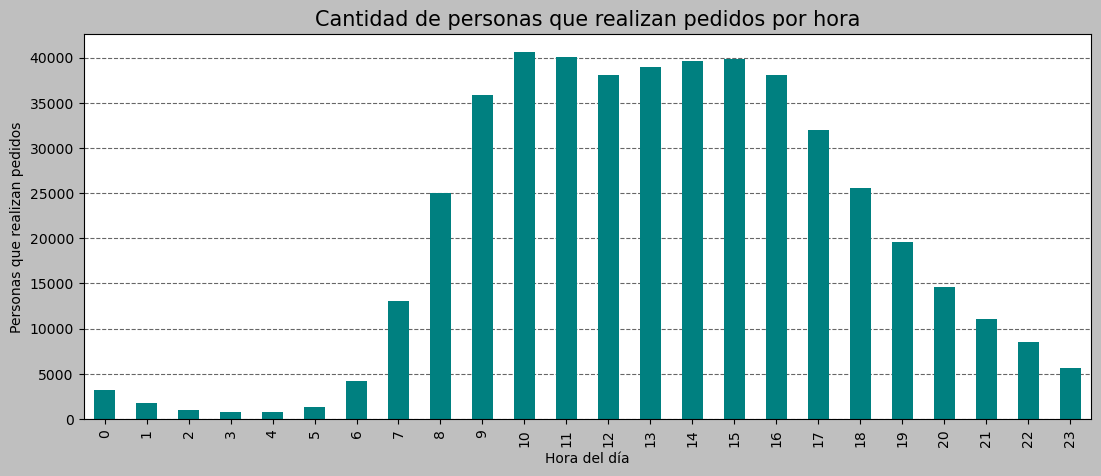

In [782]:
plt.style.use('grayscale')
pedidos_por_hora.plot(kind='bar', figsize= [13,5], color='teal', zorder=2)
plt.title('Cantidad de personas que realizan pedidos por hora', fontsize = 15)
plt.xlabel('Hora del día')
plt.ylabel('Personas que realizan pedidos')
plt.grid(True, alpha=0.6, axis='y', linestyle='--')
plt.show()

Escribe aquí tus conclusiones

> El análisis de los pedidos por hora del día revela que la mayor actividad de compras ocurre durante las horas diurnas, alcanzando un pico máximo alrededor de las 10:00, que se mantiene hasta aproximadamente las 16:00. A partir de ese momento, se observa una disminución progresiva en la cantidad de pedidos. En contraste, las horas de menor actividad corresponden al período de la madrugada, lo que refleja el comportamiento esperado de los clientes, dado que la mayoría se encuentra descansando durante esas horas. Este patrón evidencia claramente la influencia del ciclo diario en los hábitos de compra de los usuarios.

### [A3] ¿Qué día de la semana compran víveres las personas?

In [783]:
dias_semana = {0: 'Domingo', 
                1: 'Lunes', 
                2: 'Martes', 
                3: 'Miércoles', 
                4: 'Jueves', 
                5: 'Viernes', 
                6: 'Sábado'}
dia_de_compras = df_inst_order.groupby('order_dow')['user_id'].count()
dia_de_compras.index = dia_de_compras.index.map(dias_semana)


print(dia_de_compras)

order_dow
Domingo      84090
Lunes        82185
Martes       65833
Miércoles    60897
Jueves       59810
Viernes      63488
Sábado       62649
Name: user_id, dtype: int64


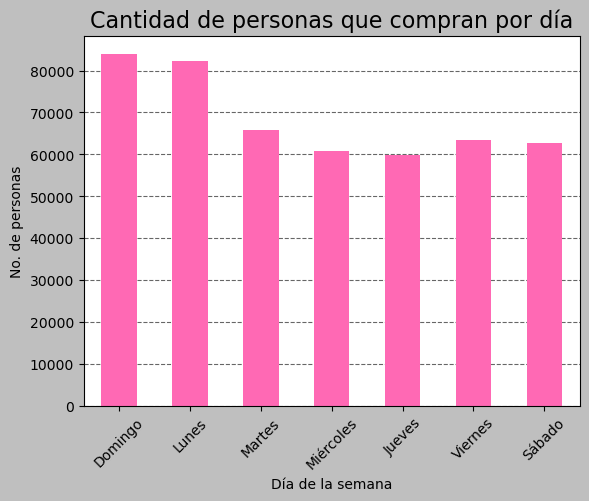

In [865]:
plt.style.use('grayscale')
dia_de_compras.plot(kind='bar',
                    xlabel='Día de la semana',
                    ylabel='No. de personas',
                    rot=45,
                    color='hotpink',
                    zorder=2)
plt.title('Cantidad de personas que compran por día', fontsize=16)
plt.grid(True, alpha=0.6, axis='y', linestyle='--')
plt.show()

Escribe aquí tus conclusiones

> De acuerdo con el gráfico, el día en que la mayoría de las personas realiza sus compras es el domingo, lo cual puede explicarse porque es el día en que la mayoría descansa y se prepara para la semana. Asimismo, se observa que la cantidad de compras disminuye progresivamente a lo largo de la semana, comenzando a aumentar nuevamente el viernes, probablemente porque muchas personas aprovechan el fin de semana para adquirir productos que necesitan reponer.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

In [785]:
df_inst_order.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [786]:
dias_entre_compras=df_inst_order.groupby('days_since_prior_order')['user_id'].count()
dias_entre_compras = dias_entre_compras.astype('int')

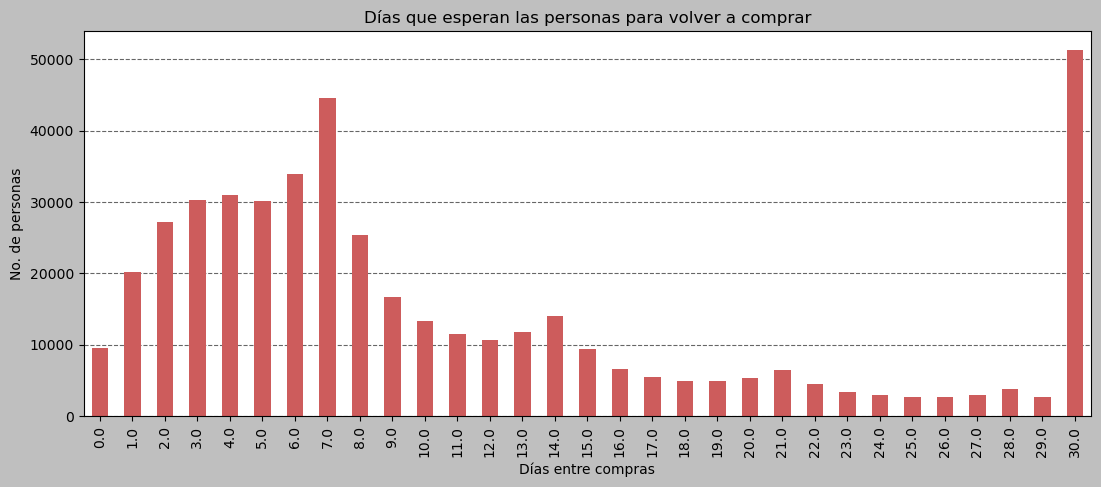

In [787]:
dias_entre_compras.plot(kind='bar', figsize=[13,5], color='indianred', zorder=2)
plt.xlabel('Días entre compras')
plt.ylabel('No. de personas')
plt.title('Días que esperan las personas para volver a comprar')
plt.grid(True, alpha=0.6, axis='y', linestyle='--')

Escribe aquí tus conclusiones

> A partir de la gráfica se pueden identificar varios patrones relevantes. Se observan picos en las compras cada 7, 14 y 30 días. Esto sugiere que muchas personas realizan adquisiciones de manera semanal, mientras que otras lo hacen quincenalmente, posiblemente coincidiendo con los periodos de pago de nómina. Además, existe un incremento importante en las compras cada 30 días, lo que indica una planificación de abastecimiento mensual. También se aprecia un grupo considerable de consumidores que efectúan compras con una frecuencia menor a una semana, aproximadamente cada cuatro días, lo que podría asociarse con compras de reposición o necesidades inmediatas.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [788]:
df_inst_order.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [789]:
miercoles = df_inst_order[df_inst_order['order_dow'] == 3] # Filtro para días miercoles
sabado = df_inst_order[df_inst_order['order_dow'] == 6] # Filtro para días sábado

# contamos cuantas veces aparece cada hora y ordenamos por indice (hora)

h_miercoles = miercoles['order_hour_of_day'].value_counts().sort_index() 
h_sabado = sabado['order_hour_of_day'].value_counts().sort_index() 

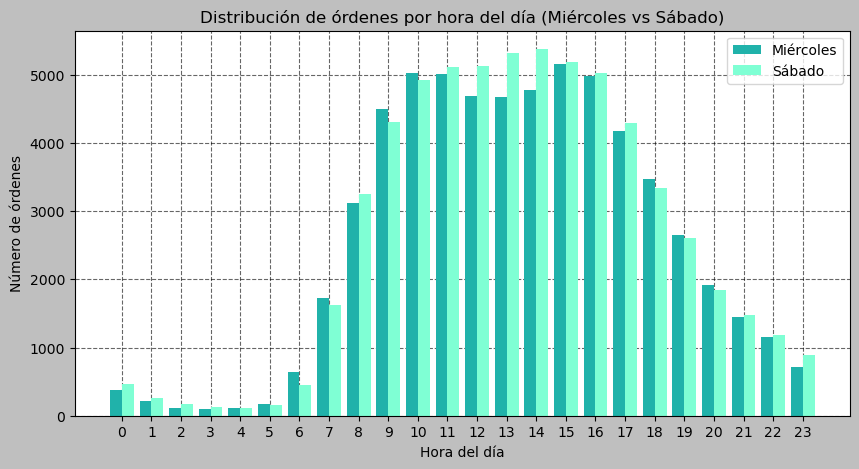

In [871]:
plt.figure(figsize=(10, 5))
plt.bar(h_miercoles.index - 0.2, 
        h_miercoles.values, 
        width=0.4, 
        label='Miércoles', 
        color='lightseagreen',
        zorder=2)
plt.bar(h_sabado.index + 0.2, 
        h_sabado.values, 
        width=0.4, 
        label='Sábado',
        color='Aquamarine',
        zorder=2)

plt.title('Distribución de órdenes por hora del día (Miércoles vs Sábado)')
plt.xlabel('Hora del día')
plt.ylabel('Número de órdenes')
plt.legend()
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Escribe aquí tus conclusiones

>  En ambos días se observa un comportamiento similar en cuanto a los horarios de compra de los usuarios. Sin embargo, durante las horas de la mañana, los miércoles registran un mayor número de pedidos. A partir de las 11:00 a.m., esta tendencia se invierte, y el sábado pasa a concentrar la mayor cantidad de compras. Esto sugiere que los usuarios tienden a realizar sus compras entre semana durante la mañana, mientras que los fines de semana prefieren hacerlo a partir del mediodía.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [791]:
pedidos_cliente = df_inst_order.groupby('user_id')['order_id'].count().value_counts()


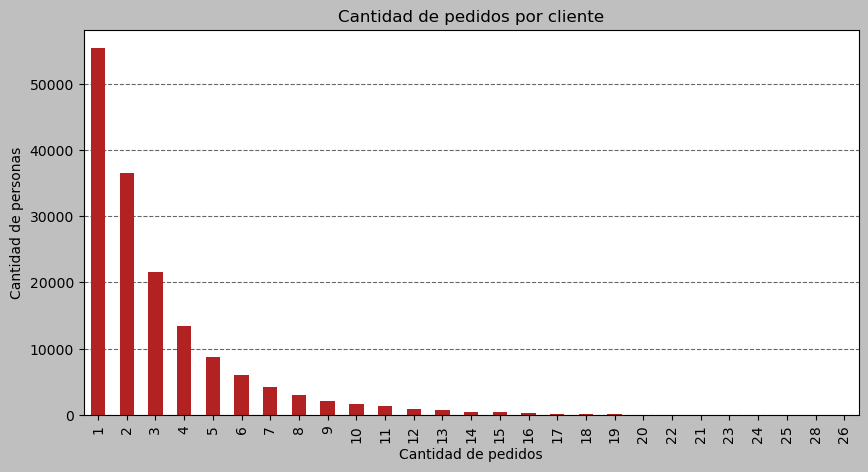

In [837]:
pedidos_cliente.plot(kind='bar',
                     title='Cantidad de pedidos por cliente',
                     xlabel='Cantidad de pedidos',
                     ylabel='Cantidad de personas',
                     figsize=[10,5], 
                     color='FireBrick',
                     zorder=2)
plt.grid(True, alpha=0.6, axis='y', linestyle='--')
plt.show()

Escribe aquí tus conclusiones

> La gran mayoría de los clientes realiza un solo pedido. Esto se refleja en que cada 30 días se registra el mayor número de pedidos, lo que sugiere que los clientes suelen hacer un pedido al mes. Según la gráfica, son muy pocas las personas que realizan más de diez pedidos mensuales.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [793]:
# buscamos en el DataFrame de order_products, ya que en este se encuentra cuántos y cuáles productos se agregan al carrito

productos_polulares = df_order_p['product_id'].value_counts().iloc[0:20] # contamos cuantas veces aparece cada producto y mostrmos los 20 más populares

# Del DataFrame de products se obtiene el nombre del producto en función del ID

nombre_producto = df_products.groupby('product_id')['product_name'].unique()

print(productos_polulares)
print(nombre_producto)

product_id
24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
47766    24689
47626    21495
16797    20018
26209    19690
27845    19600
27966    19197
22935    15898
24964    15292
45007    14584
39275    13879
49683    13675
28204    12544
5876     12232
8277     11993
40706    11781
Name: count, dtype: int64
product_id
1                             [CHOCOLATE SANDWICH COOKIES]
2                                       [ALL-SEASONS SALT]
3                   [ROBUST GOLDEN UNSWEETENED OOLONG TEA]
4        [SMART ONES CLASSIC FAVORITES MINI RIGATONI WI...
5                              [GREEN CHILE ANYTIME SAUCE]
                               ...                        
49690                      [HIGH PERFORMANCE ENERGY DRINK]
49691                      [ORIGINAL PANCAKE & WAFFLE MIX]
49692    [ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR]
49693                             [SPRING WATER BODY WASH]
49694                            [BURRITO- STEAK & CHEESE]
Nam

In [794]:
# utilizamos concat para unir los Series y obtener un DataFrame con los productos mas populares, 
# cuántas veces se pidieron y el nombre correspondiente

populares_con_nombre = pd.concat([productos_polulares, nombre_producto], axis = 1, join = 'inner')
populares_con_nombre.columns = ['veces_pedido', 'nombre_producto']

print(populares_con_nombre)

            veces_pedido             nombre_producto
product_id                                          
24852              66050                    [BANANA]
13176              53297    [BAG OF ORGANIC BANANAS]
21137              37039      [ORGANIC STRAWBERRIES]
21903              33971      [ORGANIC BABY SPINACH]
47209              29773      [ORGANIC HASS AVOCADO]
47766              24689           [ORGANIC AVOCADO]
47626              21495               [LARGE LEMON]
16797              20018              [STRAWBERRIES]
26209              19690                     [LIMES]
27845              19600        [ORGANIC WHOLE MILK]
27966              19197       [ORGANIC RASPBERRIES]
22935              15898      [ORGANIC YELLOW ONION]
24964              15292            [ORGANIC GARLIC]
45007              14584          [ORGANIC ZUCCHINI]
39275              13879       [ORGANIC BLUEBERRIES]
49683              13675            [CUCUMBER KIRBY]
28204              12544        [ORGANIC FUJI 

In [795]:
# Se le da un formato adecuado al dataFrame resultante

populares_con_nombre['nombre_producto'] = populares_con_nombre['nombre_producto'].str[0].str.capitalize()

# Se combierte el indice en columna
populares_con_nombre = populares_con_nombre.reset_index()
print(populares_con_nombre)

    product_id  veces_pedido           nombre_producto
0        24852         66050                    Banana
1        13176         53297    Bag of organic bananas
2        21137         37039      Organic strawberries
3        21903         33971      Organic baby spinach
4        47209         29773      Organic hass avocado
5        47766         24689           Organic avocado
6        47626         21495               Large lemon
7        16797         20018              Strawberries
8        26209         19690                     Limes
9        27845         19600        Organic whole milk
10       27966         19197       Organic raspberries
11       22935         15898      Organic yellow onion
12       24964         15292            Organic garlic
13       45007         14584          Organic zucchini
14       39275         13879       Organic blueberries
15       49683         13675            Cucumber kirby
16       28204         12544        Organic fuji apple
17        

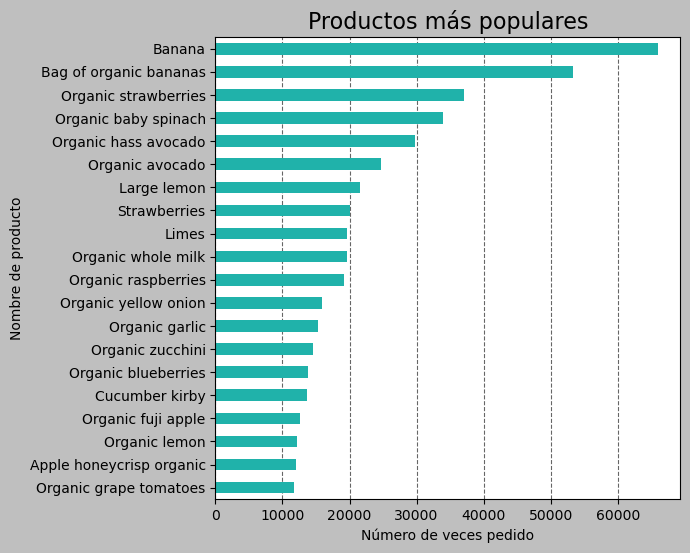

In [839]:
populares_con_nombre_sorted = populares_con_nombre.sort_values(by='veces_pedido', ascending=True)
populares_con_nombre_sorted.plot.barh(x='nombre_producto',
                                        y='veces_pedido', 
                                        ylabel = 'Nombre de producto',
                                        xlabel = 'Número de veces pedido',
                                        legend =False, 
                                        color='lightseagreen',
                                        zorder = 2,
                                        figsize = [6,6])
plt.grid(True, alpha=0.6, axis='x', linestyle='--')
plt.title(label='Productos más populares', fontsize=16)
plt.show()

Escribe aquí tus conclusiones

> La gráfica muestra que el producto más pedido es el plátano, seguido por otra presentación de plátanos (en bolsa). En general, los productos más pedidos correspendon a alimentos, especificamente, frutas y verduras. 

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [859]:
df_order_p

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17,0
1,567889,1560,1,1
2,2261212,26683,1,1
3,491251,8670,35,1
4,2571142,1940,5,1
...,...,...,...,...
4545002,577211,15290,12,1
4545003,1219554,21914,9,0
4545004,692640,47766,4,1
4545005,319435,691,8,1


In [817]:
# obtenemos la cantidad de productos por pedido

productos_por_pedido = df_order_p.groupby('order_id')['add_to_cart_order'].size()
print(productos_por_pedido.max())


127


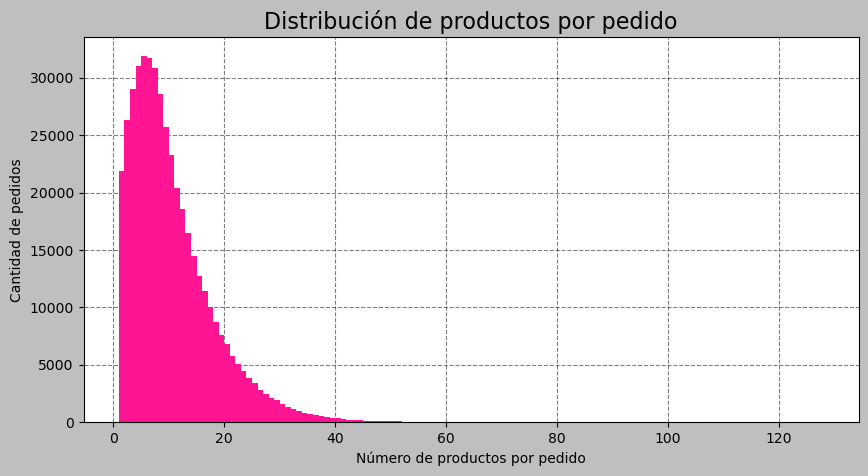

In [834]:
productos_por_pedido.plot.hist(bins=range(1, productos_por_pedido.max()+2),  # el numero de bins es igual al numero de pedidos 
                                xlabel='Número de productos por pedido',
                                ylabel='Cantidad de pedidos',
                                title='distibución de productios por pedidos',
                                color='deeppink',
                                zorder = 2,
                                figsize=[10,5])
plt.xlabel('Número de productos por pedido')
plt.ylabel('Cantidad de pedidos')
plt.title('Distribución de productos por pedido', fontsize=16)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

Escribe aquí tus conclusiones

> De acuerdo a los datos y a la gráfica, el pedido con más productos tiene un total de 127 productos, debido a esto, la gráfica se observa sesgada a la derecha. A pesar de lo anterior, podemos ver que la cantidad de productos en cada pedido es en promedio 10.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [861]:
# Calculamos el numero de veces que se vuelve a pedir un producto en funcion del ID del producto
productos_repedidos = df_order_p[df_order_p['reordered'] == 0].groupby('product_id')['reordered'].count().sort_values(ascending=False).iloc[0:20]
print(productos_repedidos)

# Reutilizando el Series donde se coloca el nombre de producto en funcion del id, obtenemos el nombre de estos articulos
nombre_producto = df_products.groupby('product_id')['product_name'].unique().str[0]

frecuencia_pedidos = pd.concat([productos_repedidos, nombre_producto], axis = 1, join = 'inner')
frecuencia_pedidos.columns = ['frecuencia_pedido', 'nombre_producto']

product_id
24852    10287
13176     8847
21137     8400
21903     7738
47626     6451
26209     6363
47209     6144
16797     6073
47766     5946
39275     5080
24964     4881
22935     4753
45007     4508
27966     4449
4605      4192
49683     4137
40706     3988
4920      3905
5876      3820
17794     3723
Name: reordered, dtype: int64


In [862]:
frecuencia_pedidos

,frecuencia_pedido,nombre_producto
product_id,,
24852,10287,BANANA
13176,8847,BAG OF ORGANIC BANANAS
21137,8400,ORGANIC STRAWBERRIES
21903,7738,ORGANIC BABY SPINACH
47626,6451,LARGE LEMON
26209,6363,LIMES
47209,6144,ORGANIC HASS AVOCADO
16797,6073,STRAWBERRIES
47766,5946,ORGANIC AVOCADO


In [863]:
# Se le da un formato adecuado al dataFrame resultante

frecuencia_pedidos['nombre_producto'] = frecuencia_pedidos['nombre_producto'].str.capitalize()

# Se combierte el indice en columna
frecuencia_pedidos = frecuencia_pedidos.reset_index()
frecuencia_pedidos

,product_id,frecuencia_pedido,nombre_producto
0,24852,10287,Banana
1,13176,8847,Bag of organic bananas
2,21137,8400,Organic strawberries
3,21903,7738,Organic baby spinach
4,47626,6451,Large lemon
5,26209,6363,Limes
6,47209,6144,Organic hass avocado
7,16797,6073,Strawberries
8,47766,5946,Organic avocado
9,39275,5080,Organic blueberries


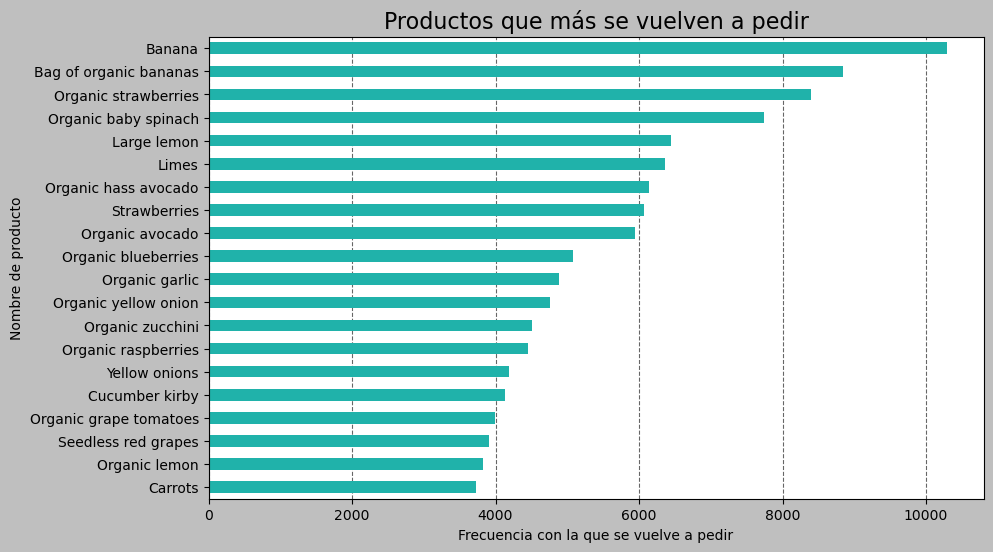

In [864]:
frecuencia_pedidos_sorted = frecuencia_pedidos.sort_values(by='frecuencia_pedido', ascending=True)
frecuencia_pedidos_sorted.plot.barh(x='nombre_producto',
                                        y='frecuencia_pedido', 
                                        ylabel = 'Nombre de producto',
                                        xlabel = 'Frecuencia con la que se vuelve a pedir',
                                        legend =False, 
                                        color='lightseagreen',
                                        zorder = 2,
                                        figsize = [10,6])
plt.grid(True, alpha=0.6, axis='x', linestyle='--')
plt.title(label='Productos que más se vuelven a pedir', fontsize=16)
plt.show()

Escribe aquí tus conclusiones

> La gráfica indica que los productos que más se repiten en las compras son alimentos, especialmente frutas y verduras, siendo los plátanos los más frecuentes. Aunque coincide parcialmente con la lista de los 20 productos más vendidos, refleja un fenómeno distinto: mientras la primera muestra qué productos se compran más en general, la segunda revela la frecuencia con la que se vuelven a adquirir durante el mes. Así, un producto muy vendido puede comprarse una sola vez por muchos clientes, mientras que otro menos popular puede repetirse varias veces entre quienes lo adquieren.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [ ]:
# 
tasa_por_producto = df_order_p.groupby('product_id')['reordered'].agg(['sum', 'count'])
tasa_por_producto['tasa_repeticion'] = tasa_por_producto['sum'] / tasa_por_producto['count']
print(tasa_por_producto)

            sum  count  tasa_repeticion
product_id                             
1           158    280         0.564286
2             0     11         0.000000
3            31     42         0.738095
4            25     49         0.510204
7             1      2         0.500000
...         ...    ...              ...
49690         4      5         0.800000
49691        31     72         0.430556
49692         5     12         0.416667
49693        11     25         0.440000
49694         3      9         0.333333

[45573 rows x 3 columns]


Escribe aquí tus conclusiones

> Conocer la tasa de repetición de un producto permite identificar cuáles son los que realmente agradan al consumidor. Por ejemplo, un nuevo producto puede generar muchas ventas iniciales debido a la curiosidad o al interés de probarlo; sin embargo, es a través de las compras repetidas cuando se demuestra la verdadera aceptación por parte de los usuarios. En este sentido, la tasa de repetición es un indicador clave para decidir si un producto debe mantenerse en el mercado o, por el contrario, descontinuarse.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [875]:
# Unimos los dataFrames de order_products y orders para tener los datos del usuario
pedidos_usuario = df_order_p.merge(df_inst_order[['order_id', 'user_id']], on='order_id')

tasa_por_usuario = pedidos_usuario.groupby('user_id')['reordered'].agg(['sum', 'count'])
tasa_por_usuario['tasa_repeticion'] = tasa_por_usuario['sum'] / tasa_por_usuario['count']

print(tasa_por_usuario)

         sum  count  tasa_repeticion
user_id                             
2          1     26         0.038462
4          0      2         0.000000
5          8     12         0.666667
6          0      4         0.000000
7         13     14         0.928571
...      ...    ...              ...
206203     6     27         0.222222
206206    15     21         0.714286
206207    41     46         0.891304
206208    87    125         0.696000
206209     8     25         0.320000

[149626 rows x 3 columns]


Escribe aquí tus conclusiones

> Conocer la proporción en la que un cliente repite sus compras permite comprender mejor sus hábitos de consumo y preferencias. Esta información resulta especialmente útil para recomendarle nuevos productos o, en caso de que alguno no esté disponible, sugerir alternativas similares basadas en sus patrones de compra. De esta manera, la tasa de repetición contribuye a personalizar la experiencia del usuario y optimizar las estrategias de recomendación.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [876]:
df_order_p.head()

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17,0
1,567889,1560,1,1
2,2261212,26683,1,1
3,491251,8670,35,1
4,2571142,1940,5,1


In [889]:
# Filtramos el DataFrame para que uinicamente se muestren las filas donde el producto se agrego primero.
primer_producto = df_order_p[df_order_p['add_to_cart_order'] == 1]

# agrupamos por ID de producto y contamos cuantas veces aparce cada uno

conteo_primeros = primer_producto.groupby('product_id').size().sort_values(ascending=False)

# Mostrar los 20 productos más frecuentes
primeros_20 = conteo_primeros[0:20]
print(primeros_20)

product_id
24852    15562
13176    11026
27845     4363
21137     3946
47209     3390
21903     3336
47766     3044
19660     2336
16797     2308
27966     2024
44632     1914
49235     1797
47626     1737
196       1733
38689     1397
26209     1370
12341     1340
5785      1310
27086     1309
22935     1246
dtype: int64


In [890]:
# Nuevamente utilizamos el Series creado con los nombres para los productos.
nombre_producto = df_products.groupby('product_id')['product_name'].unique().str[0]

primeros_20 = pd.concat([primeros_20, nombre_producto], axis = 1, join = 'inner')
primeros_20.columns = ['veces_que_fue_primero', 'nombre_producto']

primeros_20


,veces_que_fue_primero,nombre_producto
product_id,,
24852,15562,BANANA
13176,11026,BAG OF ORGANIC BANANAS
27845,4363,ORGANIC WHOLE MILK
21137,3946,ORGANIC STRAWBERRIES
47209,3390,ORGANIC HASS AVOCADO
21903,3336,ORGANIC BABY SPINACH
47766,3044,ORGANIC AVOCADO
19660,2336,SPRING WATER
16797,2308,STRAWBERRIES


In [891]:
# Se le da un formato adecuado al dataFrame resultante

primeros_20['nombre_producto'] = primeros_20['nombre_producto'].str.capitalize()

# Se combierte el indice en columna
primeros_20 = primeros_20.reset_index()
primeros_20

,product_id,veces_que_fue_primero,nombre_producto
0,24852,15562,Banana
1,13176,11026,Bag of organic bananas
2,27845,4363,Organic whole milk
3,21137,3946,Organic strawberries
4,47209,3390,Organic hass avocado
5,21903,3336,Organic baby spinach
6,47766,3044,Organic avocado
7,19660,2336,Spring water
8,16797,2308,Strawberries
9,27966,2024,Organic raspberries


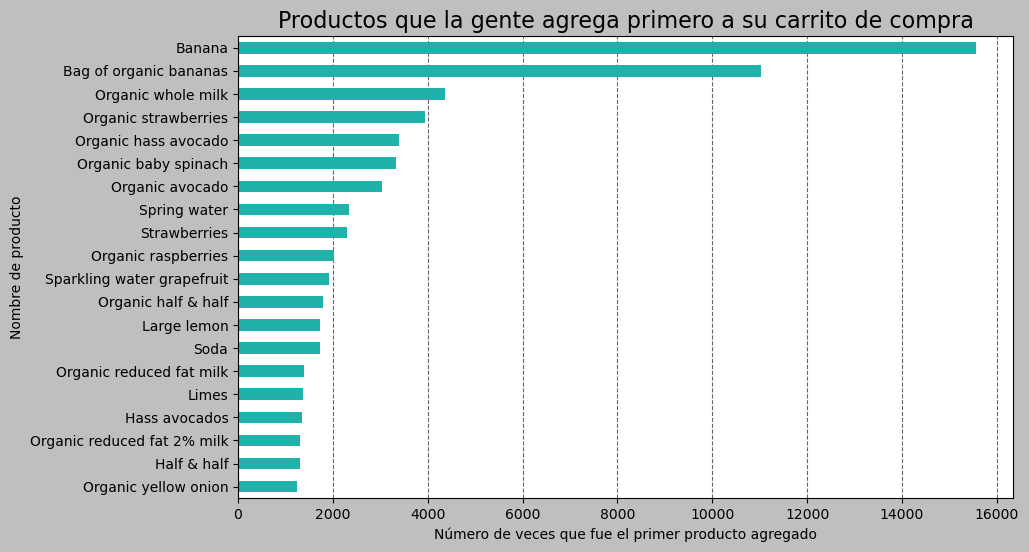

In [894]:
primeros_20 = primeros_20.sort_values(by='veces_que_fue_primero', ascending=True)
primeros_20.plot.barh(x='nombre_producto',
                                        y='veces_que_fue_primero', 
                                        ylabel = 'Nombre de producto',
                                        xlabel = 'Número de veces que fue el primer producto agregado',
                                        legend =False, 
                                        color='lightseagreen',
                                        zorder = 2,
                                        figsize = [10,6])
plt.grid(True, alpha=0.6, axis='x', linestyle='--')
plt.title(label='Productos que la gente agrega primero a su carrito de compra', fontsize=16)
plt.show()

Escribe aquí tus conclusiones

> La gráfica muestra que nuevamente, el plátano es el producto que la gente agrega primero. Se observa una gran brecha del primer y segundo producto (que ambos son plátanos) con los demas de la lista: mientras que el segundo lugar tiene un total de aprox. 15k veces que se agrega primero, el tercero no sobrepasa los 4.5 k. Así mismo, la gente suele agregar primero productos frescos. 

### Conclusion general del proyecto:

En el desarrollo de este proyecto hay varios puntos a destacar: 

1. **Conocimiento de los datos**: El primer paso en todo proyecto de análisis consiste en comprender a fondo los datos disponibles, identificando qué representa cada archivo y cada columna. Este entendimiento es fundamental para determinar qué información utilizar, cómo se relacionan las variables entre sí y qué indicadores pueden construirse a partir de ellas.

2. **Control de calidad y preparación de datos**: Una vez comprendida la estructura de los datos, es necesario realizar un proceso de control de calidad. Esto implica limpiar, depurar y acondicionar los datos para garantizar que cumplan con las condiciones adecuadas antes de proceder con los análisis, evitando errores derivados de registros duplicados, valores faltantes o inconsistencias.

Con respecto a los datos analizados, se pueden destacar los siguientes hallazgos:

1. **Calidad de los registros**: Durante la revisión y limpieza de los datos, se identificaron fallas en el sistema de registro de compras. En varios casos, se detectaron datos repetidos o incompletos, lo que sugiere que algunas transacciones no fueron registradas correctamente, generando valores ausentes.

2. **Hábitos de compra de los usuarios**: El comportamiento de los usuarios muestra un patrón de compra periódico. Se observan incrementos en las compras en intervalos de siete días, lo que indica una tendencia a realizar pedidos de manera semanal. Sin embargo, también se identificó que una parte importante de los clientes realiza sus compras de forma mensual.

3. **Productos más demandados**: Los productos más vendidos corresponden principalmente a alimentos frescos, especialmente frutas y verduras. Destaca el caso del plátano, que no solo es el producto más vendido, sino también el más recurrente en las compras mensuales y el primero en ser agregado al carrito. Esta información resulta útil para el diseño de estrategias de venta y la organización de la tienda (tanto física como en línea), permitiendo incentivar al consumidor a realizar más compras o recomendarle productos complementarios en función de sus hábitos de consumo, los cuales pueden determinarse a partir de los mismos conjuntos de datos analizados.